<a href="https://colab.research.google.com/github/young-tryler/Fashion-Store/blob/main/lab2_th_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_8267/221438091.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'szeged-weather' dataset.
KÍCH THƯỚC DATASET:  (96453, 12)


/tmp/ipykernel_8267/221438091.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Precip Type'] = X['Precip Type'].fillna('unknown')


MSE: 0.8951781087168067
RMSE: 0.9461385251202948
R2: 0.9901863031804217


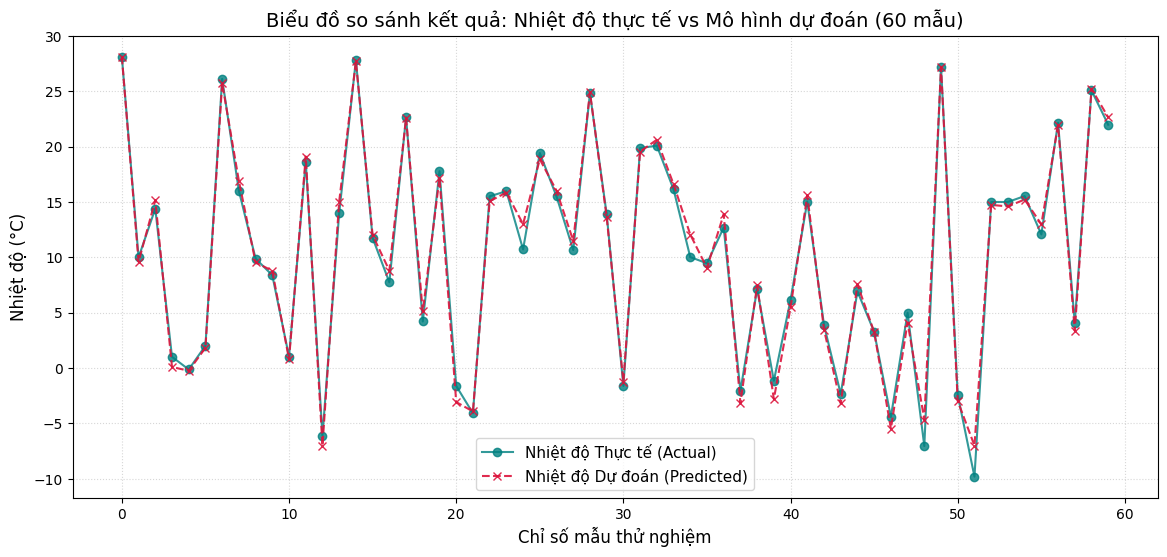

In [37]:
from sklearn import preprocessing
# Install dependencies as needed:
# !pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "weatherHistory.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,      # Muốn trả về dữ liệu dưới dạng pandas.core.frame.DataFrame
  "budincsevity/szeged-weather",    # Tên người đăng / tên dataset . Nó thấy trên link khi truy cập vào dataset https://www.kaggle.com/datasets/budincsevity/szeged-weather
  file_path,                        # Tên của file chưa dataset trên kanggle
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

# print(type(df))
# print("First 5 records:", df.head())

print("KÍCH THƯỚC DATASET: ", df.shape)
# print(df.info())

Y = df['Temperature (C)']
X = df[['Apparent Temperature (C)','Humidity','Wind Speed (km/h)','Wind Bearing (degrees)','Visibility (km)','Loud Cover','Pressure (millibars)','Precip Type']]
X['Precip Type'] = X['Precip Type'].fillna('unknown')

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42) # 30% test 70% training

# print(f"Kích thước X_train:{X_train.shape}")
# print(f"Kích thước Y_train:{Y_train.shape}")
# print(f"Kích thước X_test:{X_test.shape}")
# print(f"Kích thước Y_test:{Y_test.shape}")

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_features = ['Apparent Temperature (C)','Humidity','Wind Speed (km/h)','Wind Bearing (degrees)','Visibility (km)','Loud Cover','Pressure (millibars)']
cat_features = ['Precip Type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_processed, Y_train)

# for col, coef in zip(X.columns, model.coef_):
#   print(f"{col} : {coef}")

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

Y_pred = model.predict(X_test_processed)

mse = mean_squared_error(Y_test, Y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(Y_test, Y_pred)

print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R2: {r2}')

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Trích xuất 60 điểm dữ liệu liên tiếp từ tập test để vẽ biểu đồ sắc nét, dễ quan sát
plt.plot(Y_test.values[:60], label='Nhiệt độ Thực tế (Actual)', color='teal', marker='o', alpha=0.8)
plt.plot(Y_pred[:60], label='Nhiệt độ Dự đoán (Predicted)', color='crimson', linestyle='--', marker='x', alpha=0.9)

plt.title('Biểu đồ so sánh kết quả: Nhiệt độ thực tế vs Mô hình dự đoán (60 mẫu)', fontsize=14)
plt.xlabel('Chỉ số mẫu thử nghiệm', fontsize=12)
plt.ylabel('Nhiệt độ (°C)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
